In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline
import json
from collections import Counter
from scipy.stats import pearsonr
import math

In [33]:
def plot_specific_lemma_curves(path_dep, path_target, layer, lemma, pca=None, x_max=None, normalize=False):
    dep = pd.read_csv(path_dep, sep='\t')
    target = pd.read_csv(path_target, sep='\t')

    dep.columns = ['LAYER'] + [str(x) for x in dep.columns[1:]]
    target.columns = ['LAYER'] + [str(x) for x in target.columns[1:]]
    data_dep = dep[["LAYER", f"{lemma}", "checkpoint"]].where(dep["LAYER"] == f"Layer {layer}").dropna()
    X_dep = list(data_dep["checkpoint"])
    Y_dep = list(data_dep[f"{lemma}"])
    # normalize by the first value
    if normalize:
        Y_dep = [(y - Y_dep[0]) / (max(Y_dep) - Y_dep[0]) for y in Y_dep]

    data_target = target[["LAYER", f"{lemma}", "checkpoint"]].where(target["LAYER"] == f"Layer {layer}").dropna()
    X_target = list(data_target["checkpoint"])
    Y_target = list(data_target[f"{lemma}"])
    # normalize by the first value
    if normalize:
        Y_target = [(y - Y_target[0]) / (max(Y_target) - Y_target[0]) for y in Y_target]

    if x_max is not None:
        X_target = X_target[:x_max]
        X_dep = X_dep[:x_max]
        Y_target = Y_target[:x_max]
        Y_dep = Y_dep[:x_max]


    plt.plot(X_dep, Y_dep, label=f"{lemma}")
    plt.plot(X_target, Y_target, label="Preposition")
    plt.legend()
    if pca is None:
        plt.title(f"Layer {layer} - {lemma}")
    else:
        plt.title(f"Layer {layer} - {lemma} - PCA {pca}")
    plt.xlabel("Checkpoint")
    plt.ylabel("Classification Accuracy")
    
    plt.show()


In [32]:
def plot_all_lemma_curves(path_dep, path_target, layer, pca=None, x_max=None):
    dep = pd.read_csv(path_dep, sep='\t')
    target = pd.read_csv(path_target, sep='\t')

    dep.columns = ['layer'] + [str(x) for x in dep.columns[1:]]
    target.columns = ['layer'] + [str(x) for x in target.columns[1:]]

    all_lemmas = [x for x in dep.columns if x.isalpha() and x != "checkpoint" and x!= "layer"]
    for lemma in all_lemmas:
        data_dep = dep[["layer", f"{lemma}", "checkpoint"]].where(dep["layer"] == f"Layer {layer}").dropna()
        X_dep = list(data_dep["checkpoint"])
        Y_dep = list(data_dep[f"{lemma}"])
        #normalize by the first value
        Y_dep = [(x - Y_dep[0]) / (max(Y_dep) - Y_dep[0]) for x in Y_dep]

        data_target = target[["layer", f"{lemma}", "checkpoint"]].where(target["layer"] == f"Layer {layer}").dropna()
        X_target = list(data_target["checkpoint"])
        Y_target = list(data_target[f"{lemma}"])
        #normalize by the first value
        Y_target = [(x - Y_target[0]) / (max(Y_target) - Y_target[0])  for x in Y_target]

        if x_max is not None:
            X_target = X_target[:x_max]
            X_dep = X_dep[:x_max]
            Y_target = Y_target[:x_max]
            Y_dep = Y_dep[:x_max]


        plt.plot(X_dep, Y_dep, label="Verb")
        plt.plot(X_target, Y_target, label="Preposition")
        plt.legend()
        if pca is None:
            plt.title(f"Layer {layer} - {lemma}")
        else:
            plt.title(f"Layer {layer} - {lemma} - PCA {pca}")
        plt.xlabel("Checkpoint")
        plt.ylabel("Classification Accuracy")
        
        plt.show()


In [4]:
def get_checkpoint_1_0(path_dep, layer, lemma):
    dep = pd.read_csv(path_dep, sep="\t")
    dep.columns = ['LAYER'] + [str(x) for x in dep.columns[1:]]
    checkpoint = []

    data_dep = dep[["LAYER", f"{lemma}", "checkpoint"]].where(dep["LAYER"] == f"Layer {layer}").dropna()
    X_dep = list(data_dep["checkpoint"])
    Y_dep = list(data_dep[f"{lemma}"])
    for i, y in enumerate(Y_dep):
        if y == 1.0:
            checkpoint.append(X_dep[i])
    
    return min(checkpoint) if checkpoint else None

In [5]:
pca4_dep = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
pca4_target = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"


In [5]:
# verb statistics in dataset
ditrans_json_path = "/nlp/scr/jjian/datasets/wikitext_parsed/ditransitive.parsed_filtered.balanced_sampled.json"
ditrans_json = json.load(open(ditrans_json_path, "r"))


motion_json = "/nlp/scr/jjian/datasets/wikitext_parsed/motion.parsed_filtered.balanced_sampled.json"
motion_json = json.load(open(motion_json, "r"))

print("Verb Counts Ditransitives")
ditrans_counts = Counter([x["dependent_lemma"] for x in ditrans_json])
# sort the above
ditrans_counts = dict(sorted(ditrans_counts.items(), key=lambda item: item[1], reverse=False))
print(ditrans_counts)
# print the list of ones above 50
print([x for x in ditrans_counts if ditrans_counts[x] > 50])

print("Verb Counts Motion")
motion_counts = Counter([x["dependent_lemma"] for x in motion_json])
# sort the above
motion_counts = dict(sorted(motion_counts.items(), key=lambda item: item[1], reverse=False))
print(motion_counts)
# print the list of ones above 50
print([x for x in motion_counts if motion_counts[x] > 50])


Verb Counts Ditransitives
{'refund': 5, 'bequeath': 8, 'ask': 17, 'dictate': 22, 'yield': 22, 'guarantee': 29, 'tell': 31, 'mail': 32, 'allot': 33, 'forward': 39, 'promise': 39, 'trade': 53, 'rent': 56, 'cede': 63, 'relay': 72, 'read': 73, 'lease': 74, 'feed': 74, 'explain': 74, 'deny': 74, 'teach': 74, 'allocate': 74, 'issue': 74, 'show': 74, 'pass': 74, 'grant': 74, 'award': 74, 'deliver': 74, 'present': 74, 'offer': 74, 'pay': 74, 'sell': 74, 'assign': 74, 'transfer': 74, 'give': 74}
['trade', 'rent', 'cede', 'relay', 'read', 'lease', 'feed', 'explain', 'deny', 'teach', 'allocate', 'issue', 'show', 'pass', 'grant', 'award', 'deliver', 'present', 'offer', 'pay', 'sell', 'assign', 'transfer', 'give']
Verb Counts Motion
{'canoe': 1, 'trudge': 1, 'kayak': 1, 'trek': 2, 'stride': 2, 'vault': 2, 'trot': 2, 'hop': 2, 'exit': 2, 'scurry': 3, 'bike': 3, 'raft': 3, 'dart': 3, 'speed': 5, 'lurch': 5, 'inch': 5, 'gallop': 5, 'paddle': 6, 'creep': 7, 'stagger': 7, 'meander': 8, 'stumble': 9, 'hi

Ditransitives


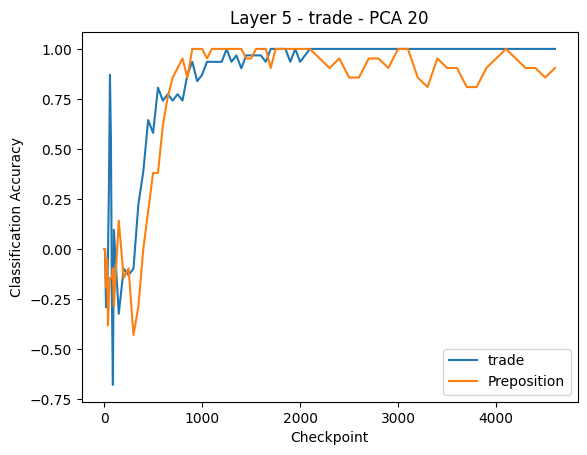

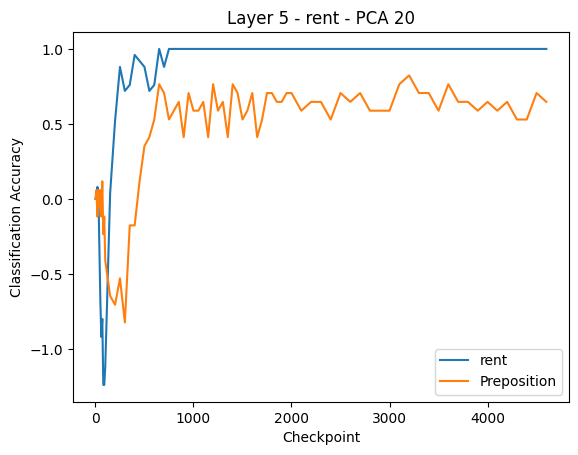

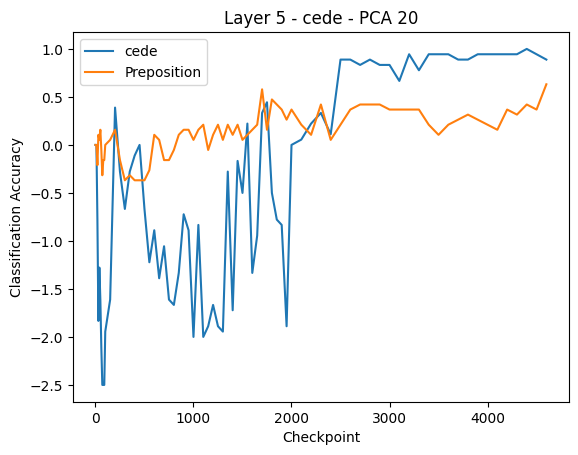

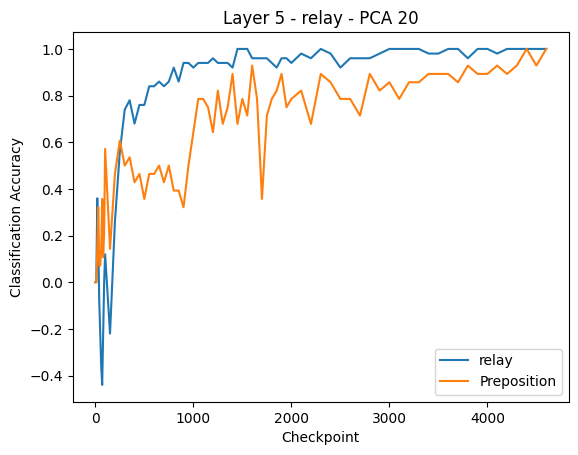

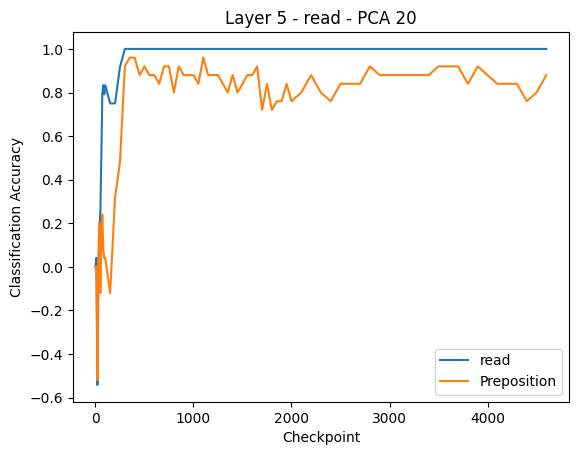

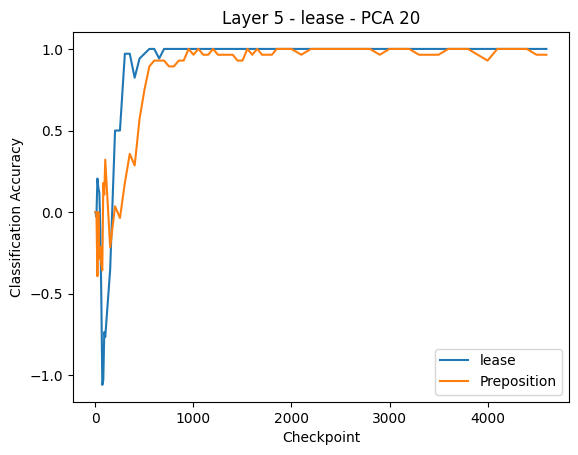

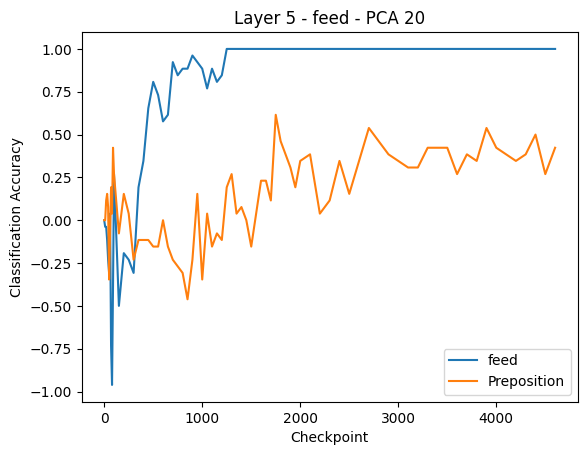

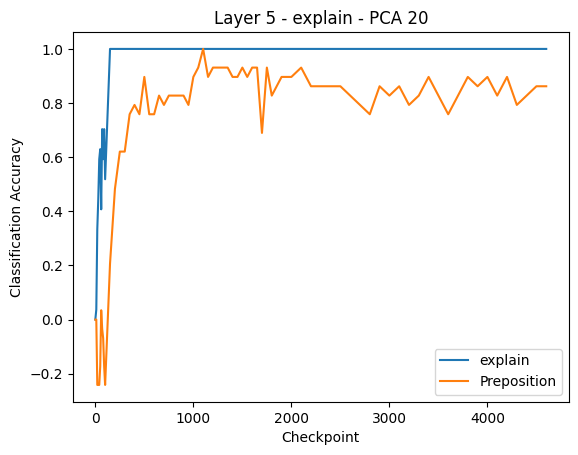

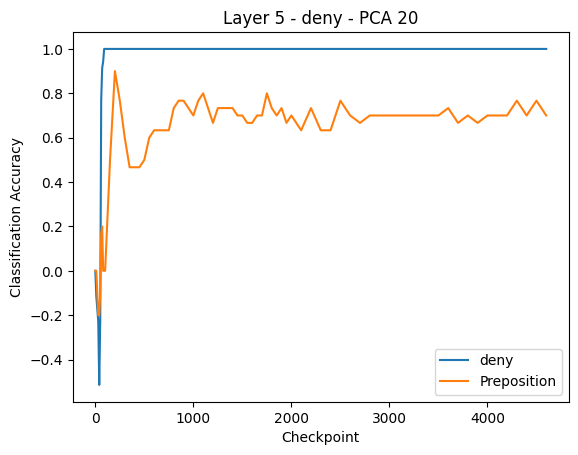

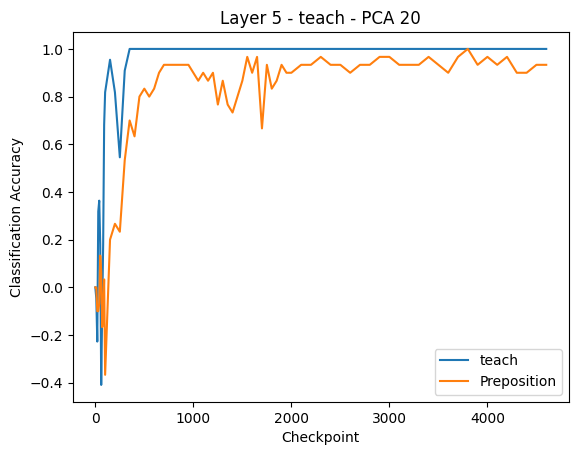

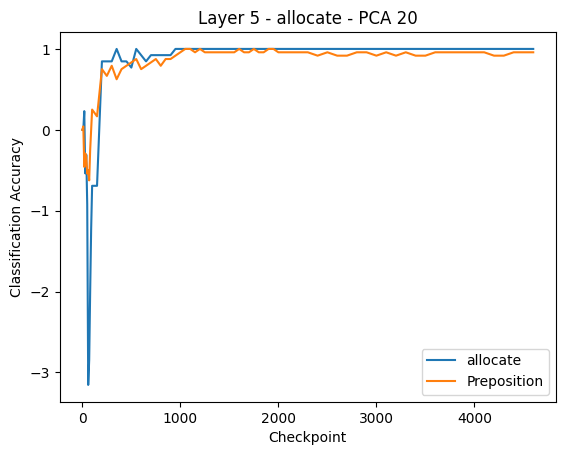

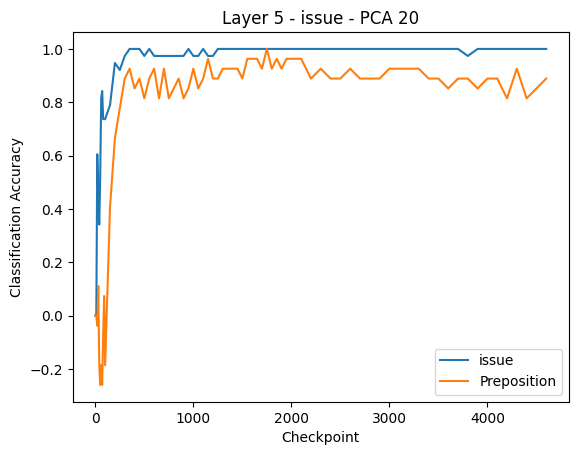

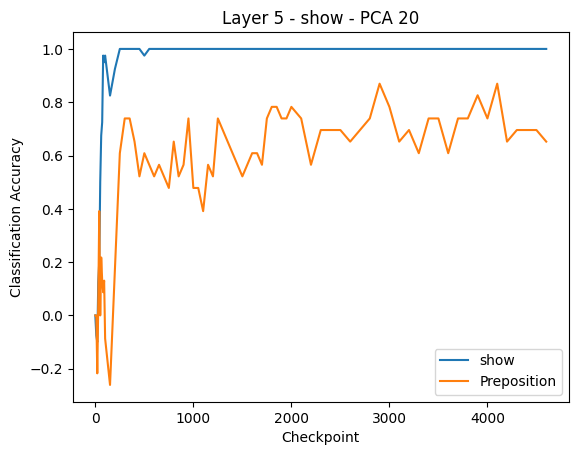

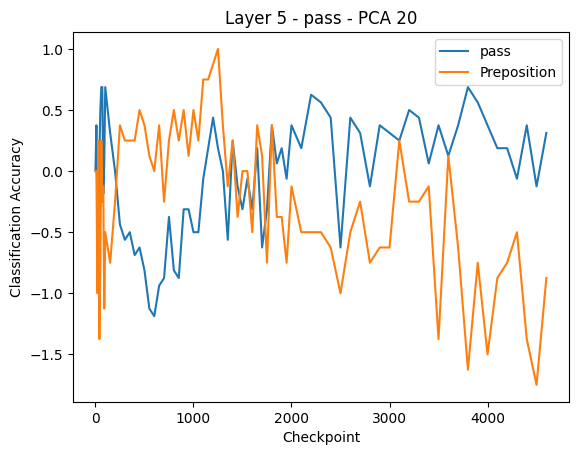

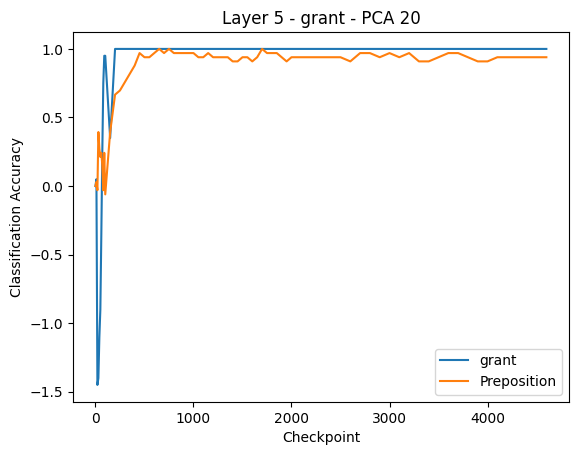

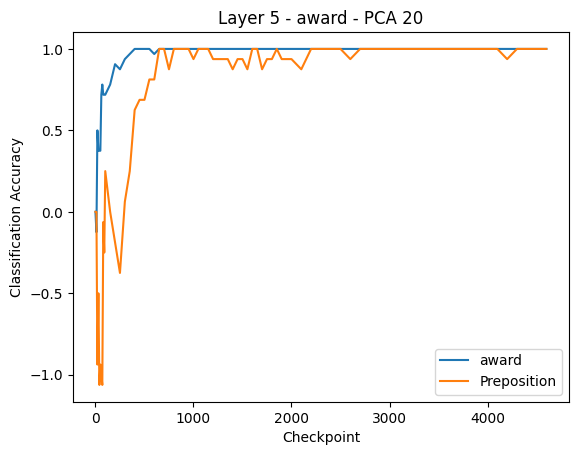

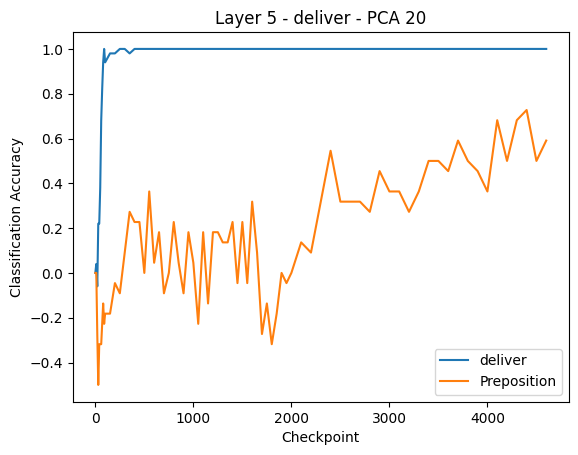

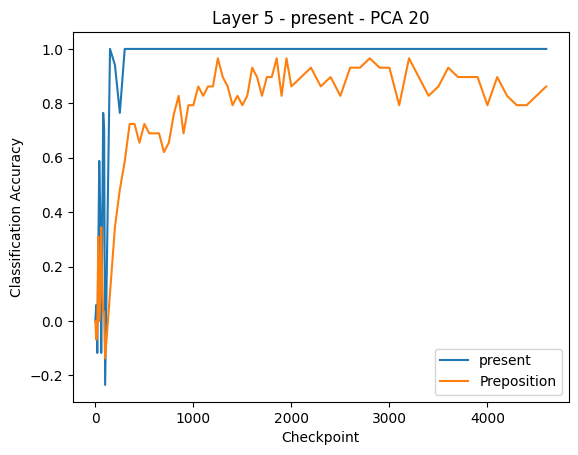

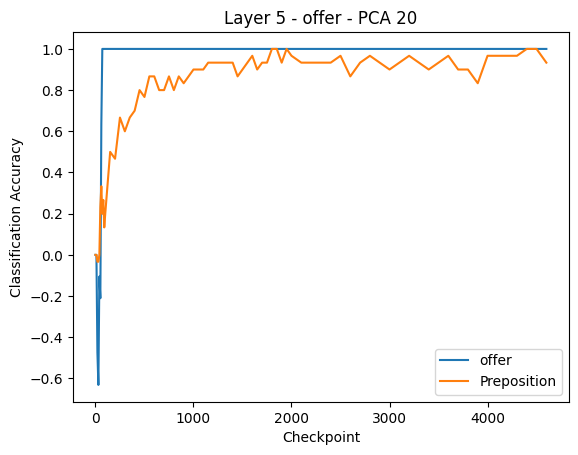

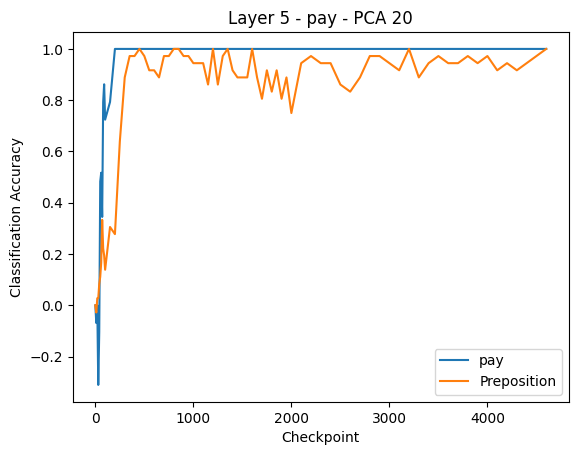

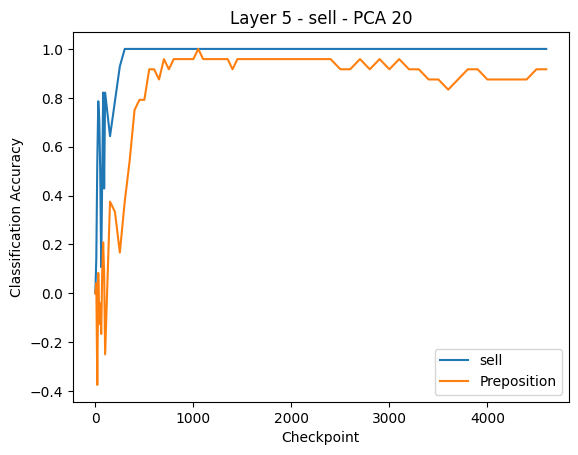

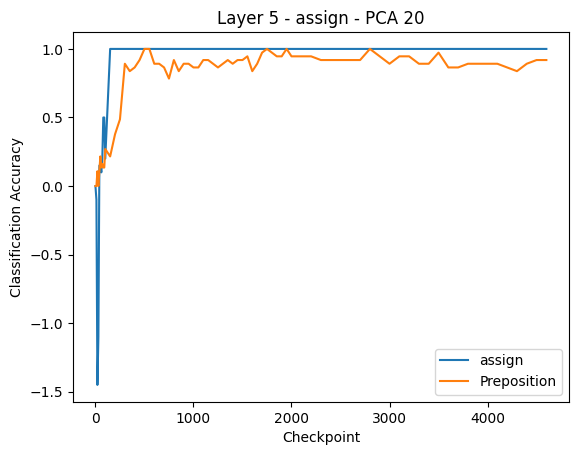

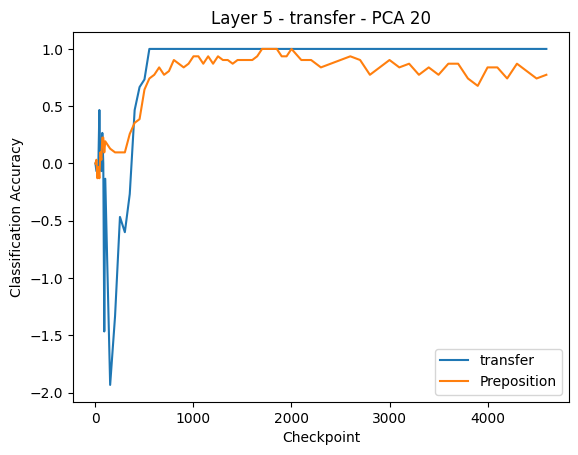

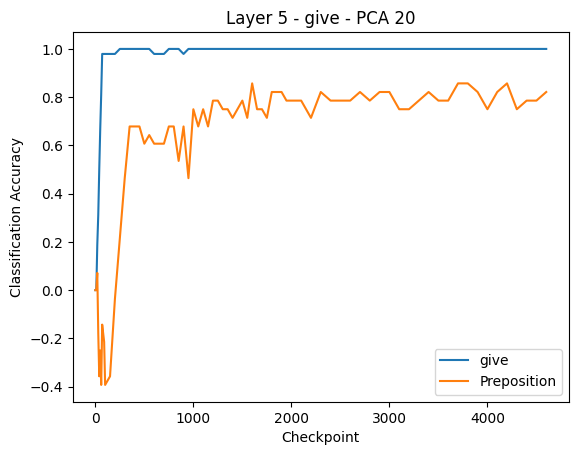

Motion


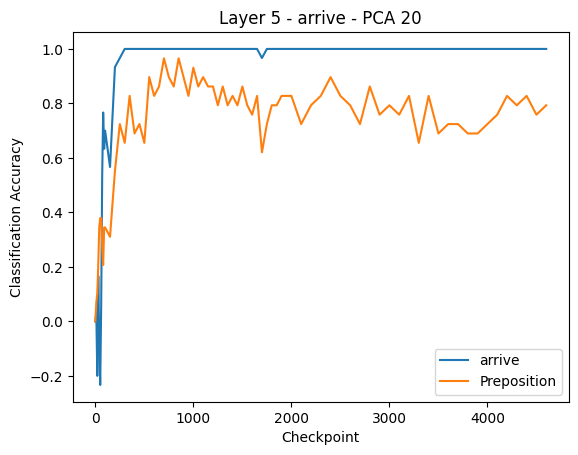

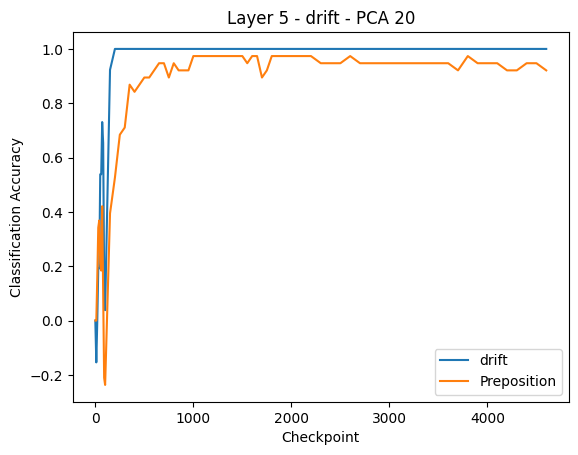

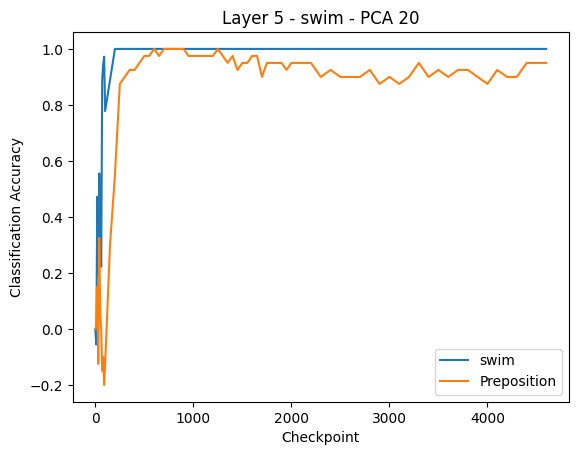

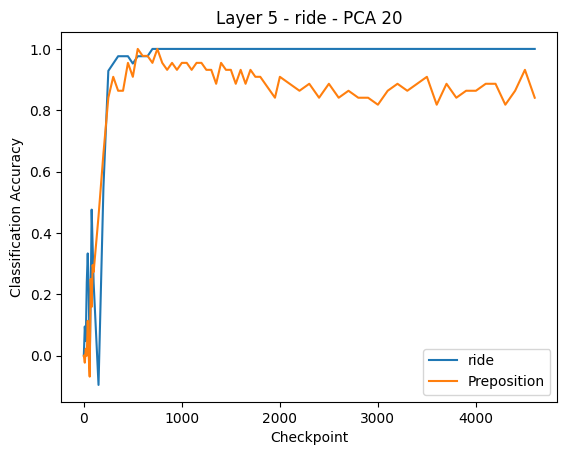

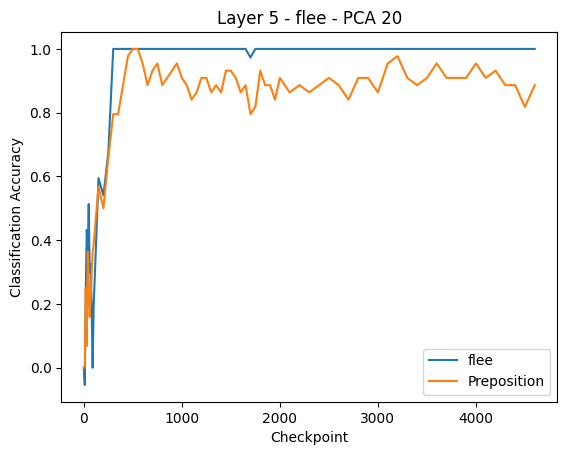

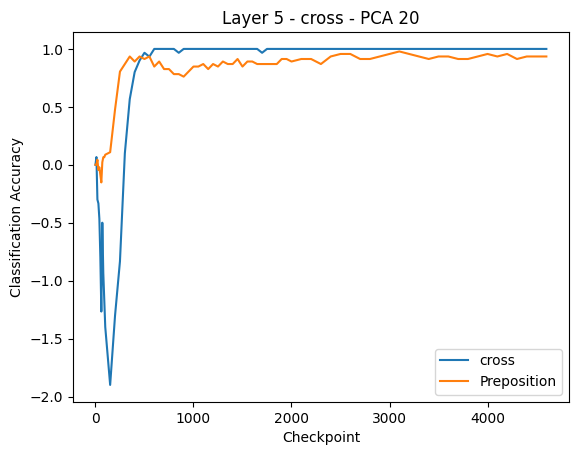

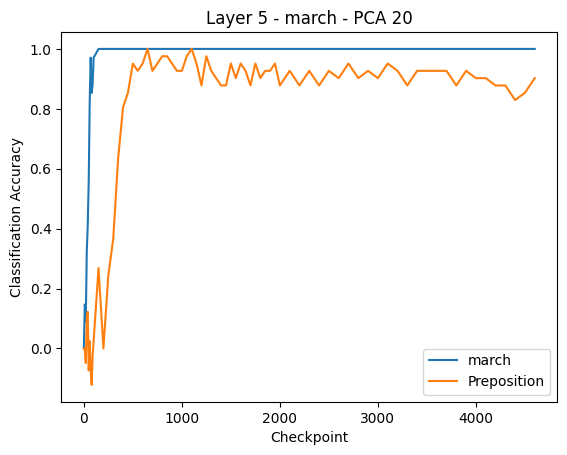

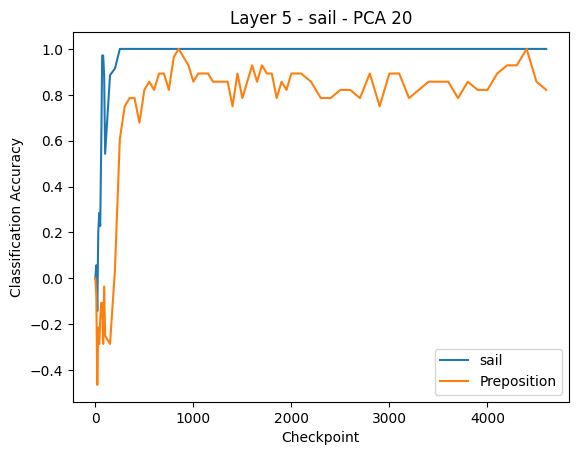

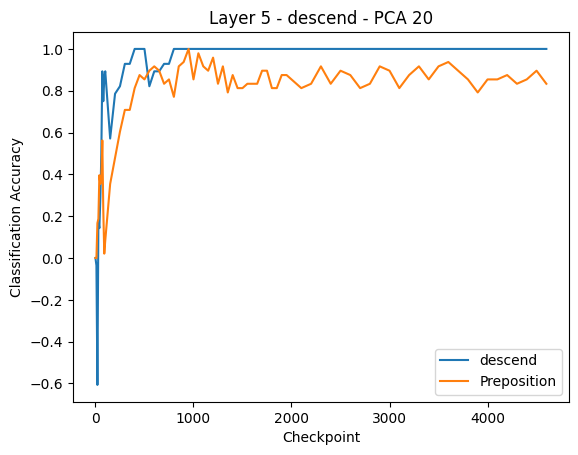

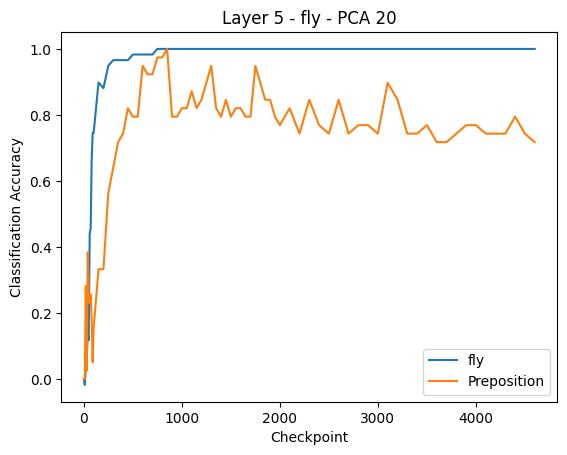

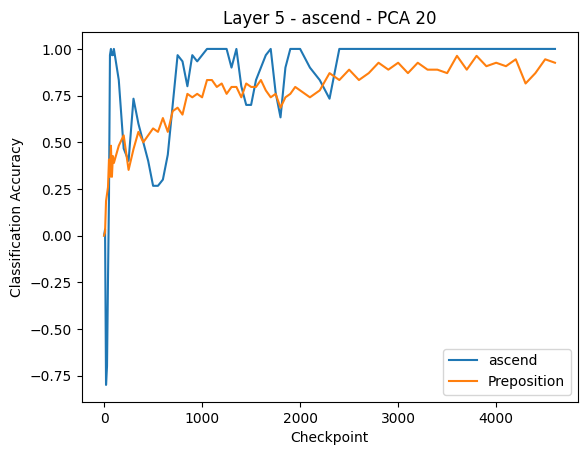

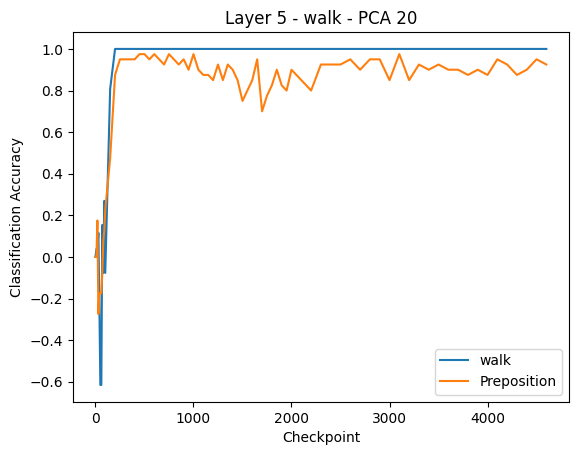

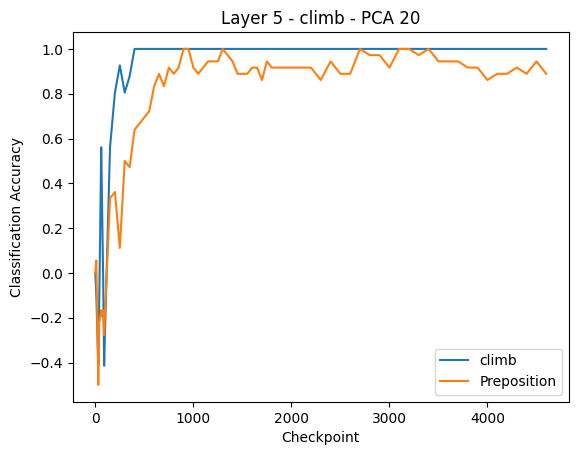

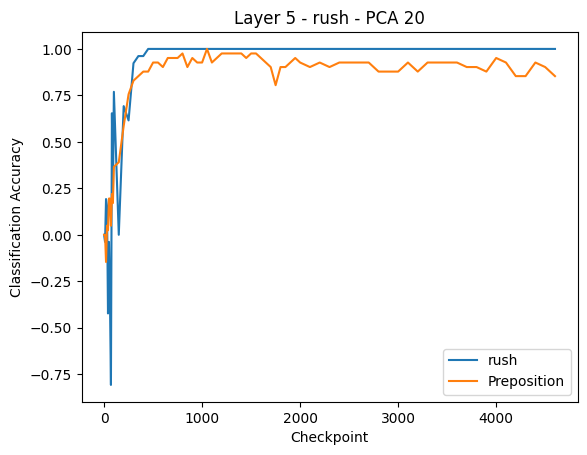

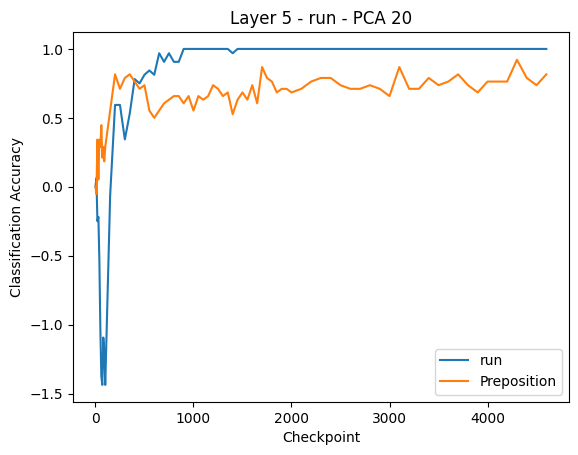

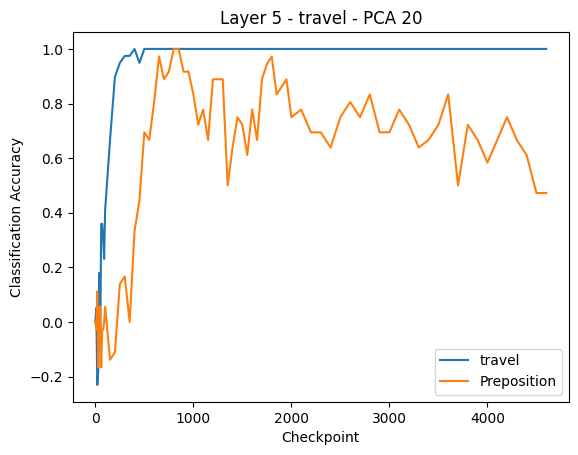

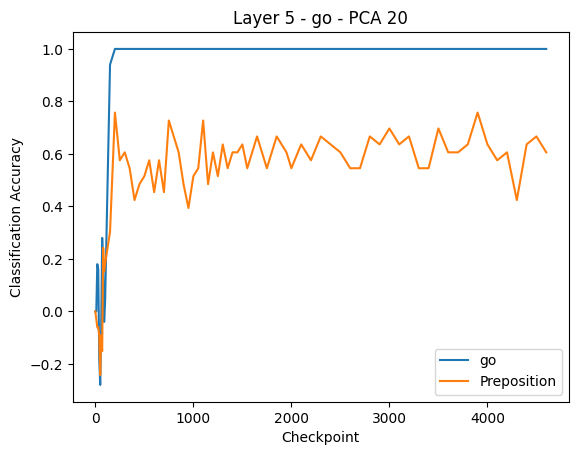

In [34]:
ditrans_over_50 = [x for x in ditrans_counts if ditrans_counts[x] > 50]
motion_over_50 = [x for x in motion_counts if motion_counts[x] > 50]

pca20_dep = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
pca20_target = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"

# plot all of these onto a single plot with subplots

print("Ditransitives")
for lemma in ditrans_over_50:
    plot_specific_lemma_curves(pca20_dep, pca20_target, 5, lemma, pca=20, x_max=75, normalize=True)

print("Motion")
for lemma in motion_over_50:
    plot_specific_lemma_curves(pca20_dep, pca20_target, 5, lemma, pca=20, x_max=75, normalize=True)

Ditransitives


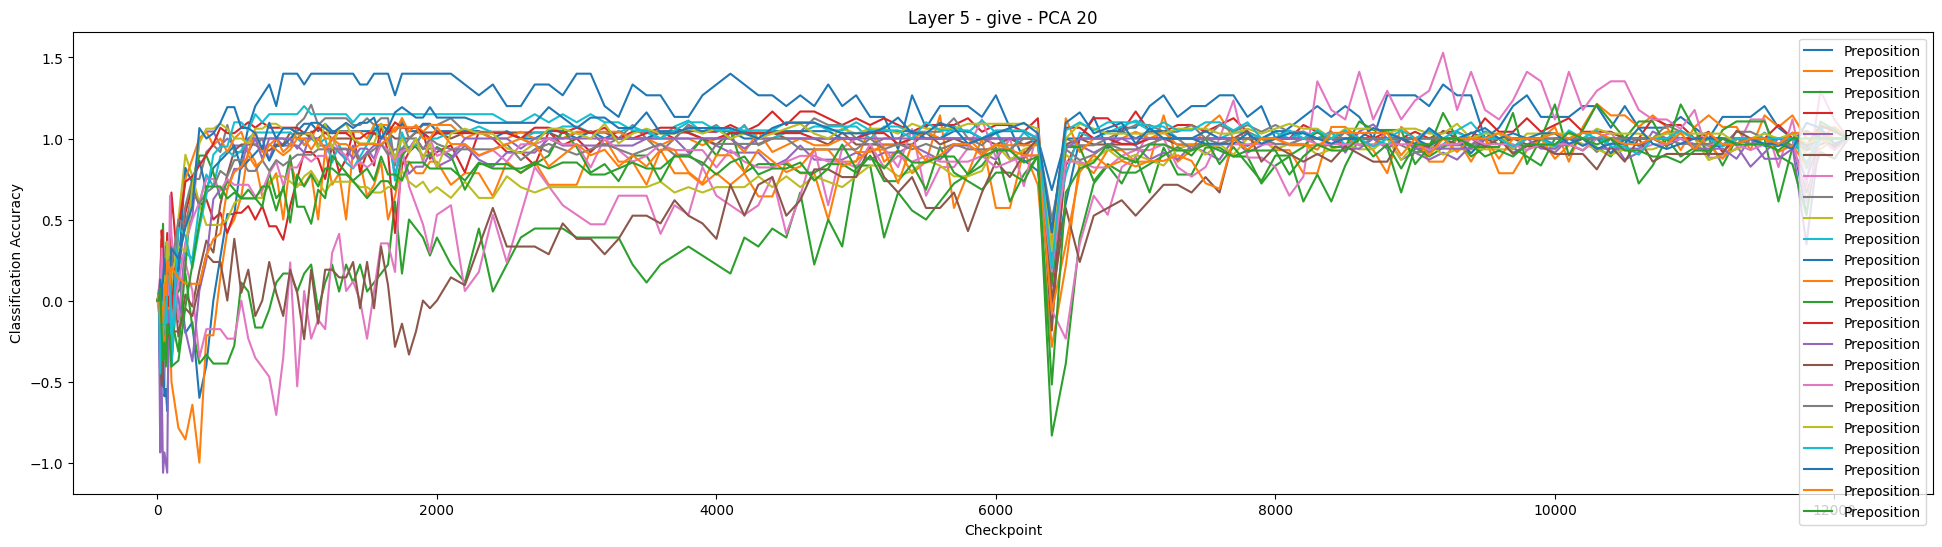

In [23]:
pca20_dep = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"
pca20_target = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/lemma/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
plt.figure(figsize=(24, 6))
print("Ditransitives")
for lemma in ditrans_over_50:
    if lemma not in ["pass"]:
        plot_specific_lemma_curves(pca20_dep, pca20_target, 5, lemma, pca=20, x_max=600, normalize=True)
plt.show()

In [8]:
ditrans_saturation_points = {}
motion_saturation_points = {}

for lemma in ditrans_over_50:
    saturation_point = get_checkpoint_1_0(pca20_dep, 5, lemma)
    ditrans_saturation_points[lemma] = saturation_point

for lemma in motion_over_50:
    saturation_point = get_checkpoint_1_0(pca20_dep, 5, lemma)
    motion_saturation_points[lemma] = saturation_point

In [10]:
all_ditrans_path="/nlp/scr/jjian/datasets/wikitext_parsed/ditransitive.parsed_filtered.json"
all_ditrans = json.load(open(all_ditrans_path, "r"))

all_motion_path="/nlp/scr/jjian/datasets/wikitext_parsed/motion.parsed_filtered.json"
all_motion = json.load(open(all_motion_path, "r"))

all_ditrans_counts = Counter([x["dependent_lemma"] for x in all_ditrans])
all_motion_counts = Counter([x["dependent_lemma"] for x in all_motion])

print(all_ditrans_counts)
print(all_motion_counts)

Counter({'give': 4960, 'transfer': 1395, 'assign': 1349, 'sell': 1222, 'pay': 776, 'offer': 688, 'present': 596, 'deliver': 550, 'award': 505, 'grant': 474, 'pass': 452, 'show': 373, 'issue': 311, 'allocate': 173, 'teach': 139, 'deny': 97, 'explain': 95, 'feed': 93, 'lease': 91, 'read': 76, 'relay': 72, 'cede': 63, 'rent': 56, 'trade': 53, 'promise': 39, 'forward': 39, 'allot': 33, 'mail': 32, 'tell': 31, 'guarantee': 29, 'yield': 22, 'dictate': 22, 'ask': 17, 'bequeath': 8, 'refund': 5})
Counter({'go': 5094, 'travel': 721, 'run': 598, 'rush': 299, 'climb': 246, 'walk': 230, 'ascend': 224, 'fly': 220, 'descend': 141, 'sail': 137, 'march': 128, 'cross': 121, 'flee': 121, 'ride': 109, 'swim': 96, 'drift': 79, 'arrive': 70, 'hurry': 49, 'race': 47, 'float': 35, 'journey': 31, 'depart': 25, 'crawl': 23, 'row': 16, 'taxi': 15, 'limp': 14, 'glide': 13, 'scramble': 12, 'dash': 12, 'plunge': 12, 'chase': 12, 'hasten': 12, 'cycle': 11, 'wander': 11, 'tumble': 10, 'skate': 10, 'hike': 10, 'stumb

PearsonRResult(statistic=-0.43684231285736375, pvalue=0.037139952448848164)


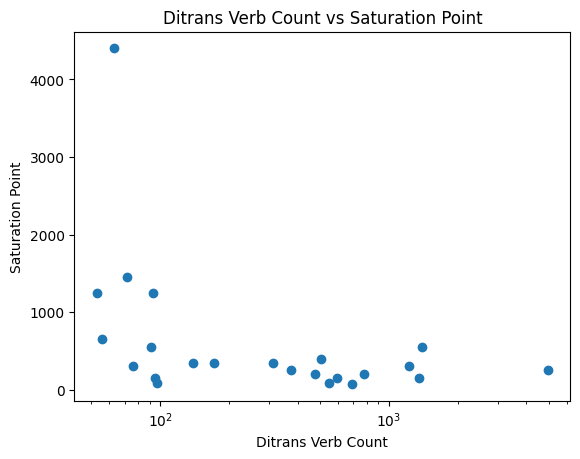

In [31]:
# plot a correlation between the ditrans counts and ditrans saturation points

x = []
y = []

for lemma in ditrans_saturation_points:
    if lemma in all_ditrans_counts and ditrans_saturation_points[lemma] != None:
        x.append(all_ditrans_counts[lemma])
        y.append(ditrans_saturation_points[lemma])

log_freq = [math.log(x) for x in x]
print(pearsonr(log_freq, y))



plt.scatter(x, y)
plt.xlabel("Ditrans Verb Count")
plt.xscale("log")
plt.ylabel("Saturation Point")
plt.title("Ditrans Verb Count vs Saturation Point")
plt.show()


PearsonRResult(statistic=0.37808148566318744, pvalue=0.14876783274572533)


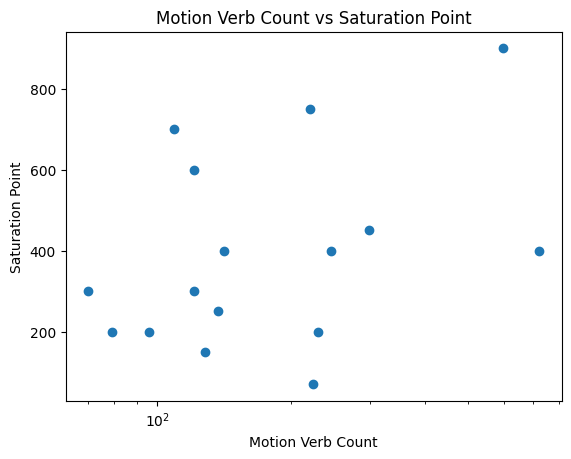

In [34]:
# do the same with motion verbs
x = []
y = []

for lemma in motion_saturation_points:
    if lemma in all_motion_counts and lemma != "go":
        x.append(all_motion_counts[lemma])
        y.append(motion_saturation_points[lemma])

log_freq = [math.log(x) for x in x]
print(pearsonr(log_freq, y))

plt.scatter(x, y)
plt.xlabel("Motion Verb Count")
plt.xscale("log")
plt.ylabel("Saturation Point")
plt.title("Motion Verb Count vs Saturation Point")
plt.show()

In [12]:
# verb statistics in dataset
substance_json_path = "/nlp/scr/jjian/datasets/wikitext_parsed/with.substance.parsed_filtered.manual.json"
substance_json = json.load(open(substance_json_path, "r"))


adjunct_json = "/nlp/scr/jjian/datasets/wikitext_parsed/with.adjunct.parsed_filtered.sampled.json"
adjunct_json = json.load(open(adjunct_json, "r"))

print("Verb Counts Ditransitives")
substance_counts = Counter([x["dependent_lemma"] for x in substance_json])
# sort the above
substance_counts = dict(sorted(substance_counts.items(), key=lambda item: item[1], reverse=False))
print(substance_counts)
# print the list of ones above 50
print([x for x in substance_counts if substance_counts[x] > 20])

Verb Counts Ditransitives
{'slather': 1, 'smudge': 1, 'sew': 1, 'string': 1, 'daub': 1, 'strew': 2, 'spatter': 2, 'sow': 3, 'squirt': 4, 'splash': 5, 'heap': 5, 'cram': 5, 'dust': 5, 'drape': 6, 'pump': 6, 'jam': 11, 'scatter': 11, 'seed': 12, 'crowd': 12, 'sprinkle': 12, 'plaster': 13, 'rub': 13, 'wrap': 14, 'smear': 16, 'stack': 17, 'hang': 20, 'stuff': 30, 'shower': 37, 'plant': 38, 'spray': 46, 'pack': 59, 'stock': 82, 'inject': 96, 'load': 126}
['stuff', 'shower', 'plant', 'spray', 'pack', 'stock', 'inject', 'load']


Substance with


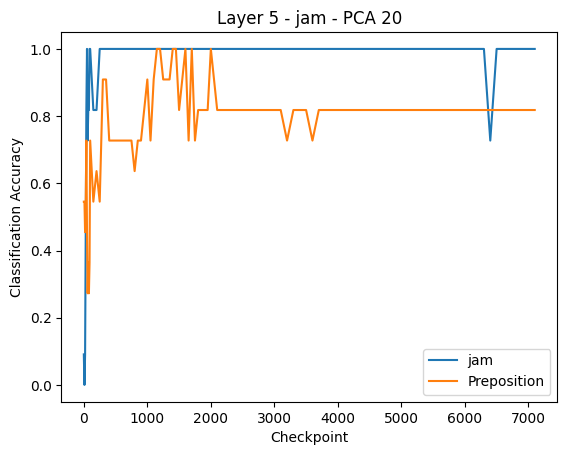

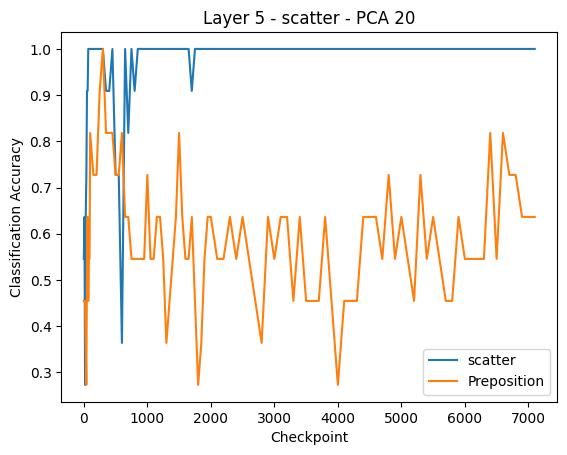

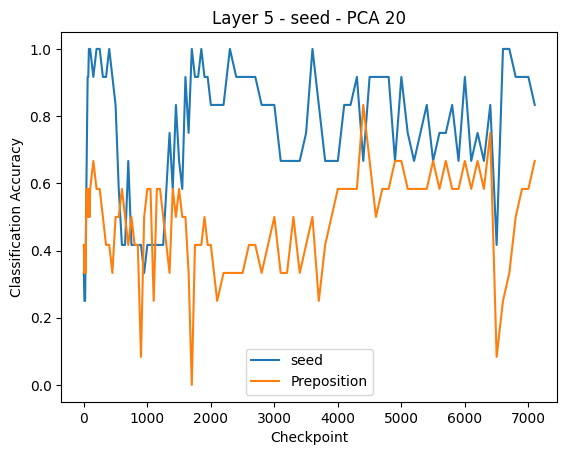

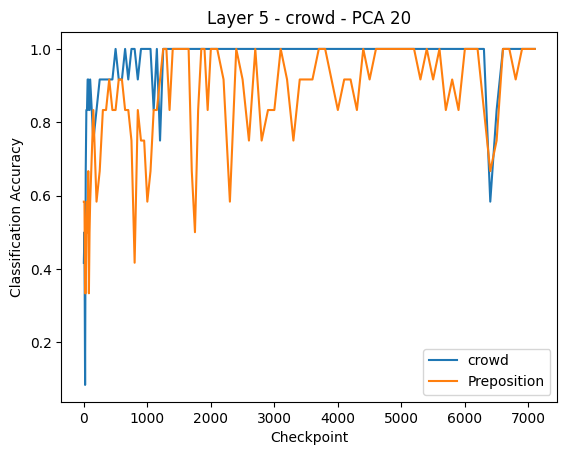

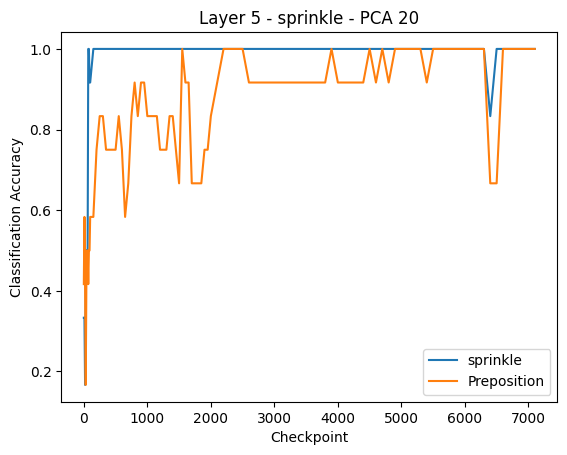

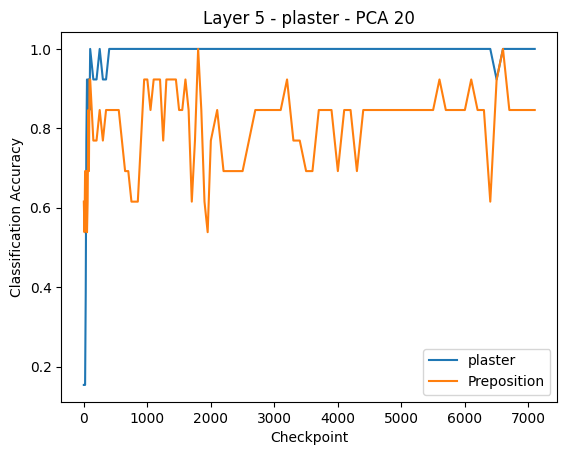

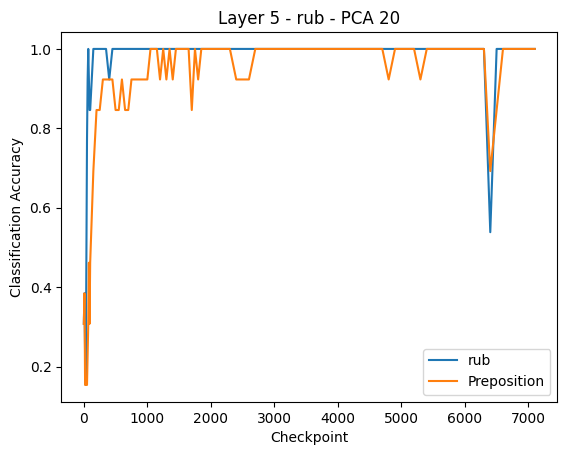

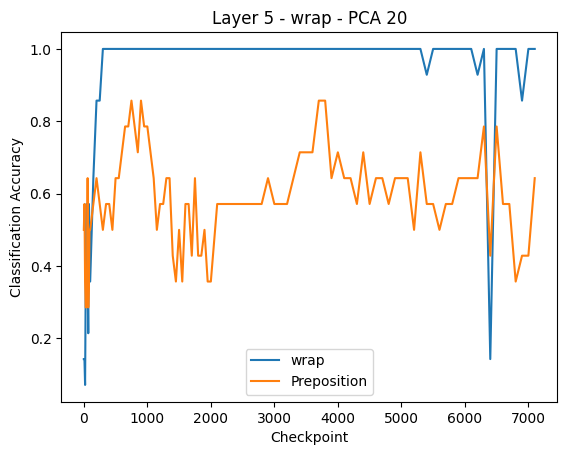

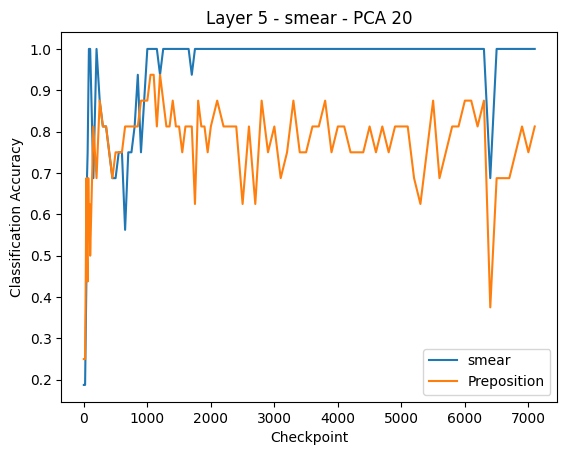

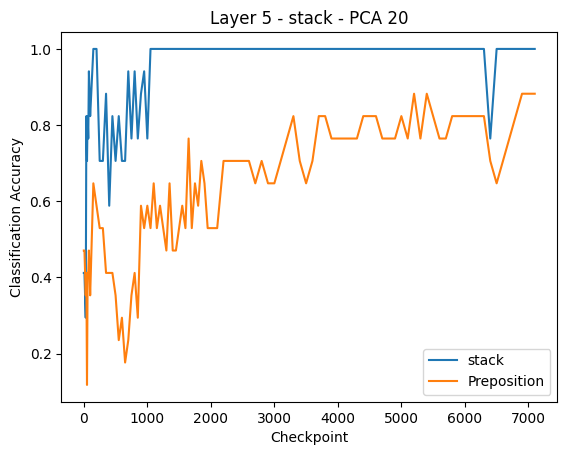

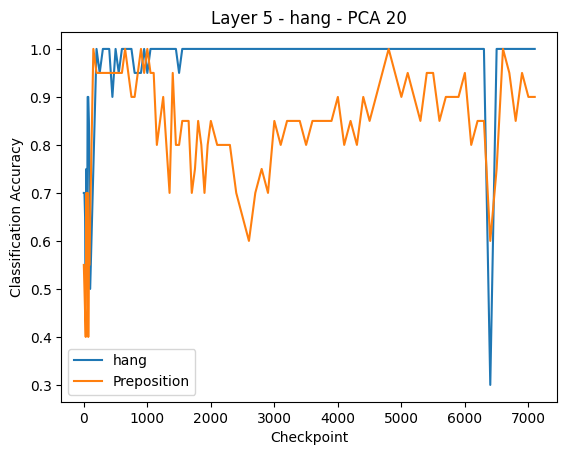

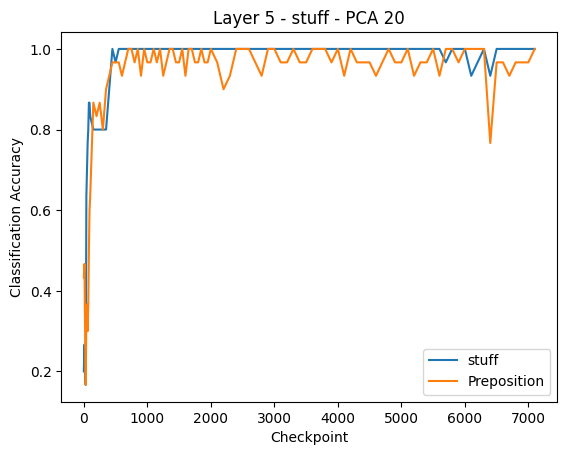

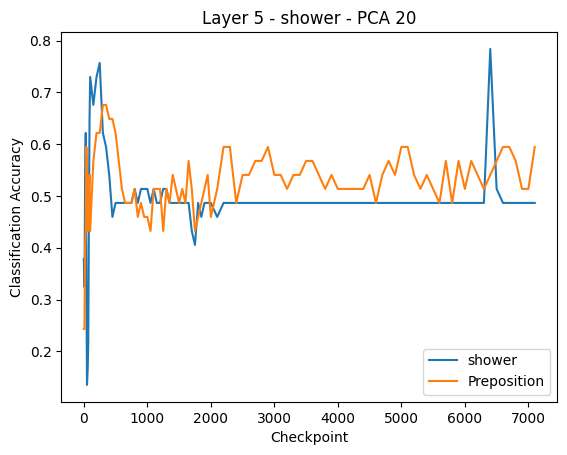

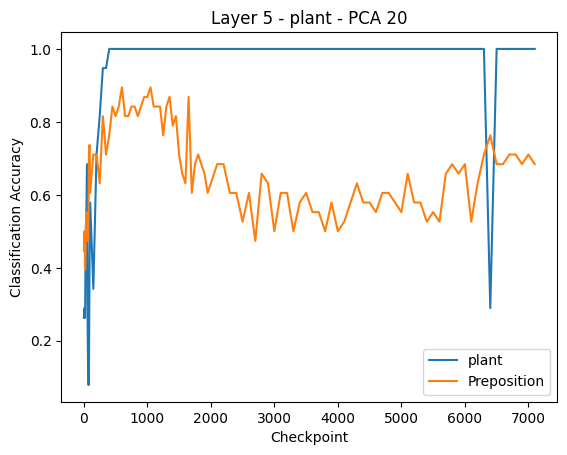

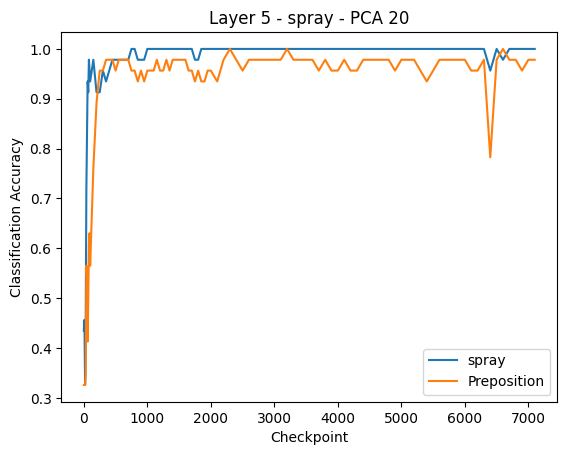

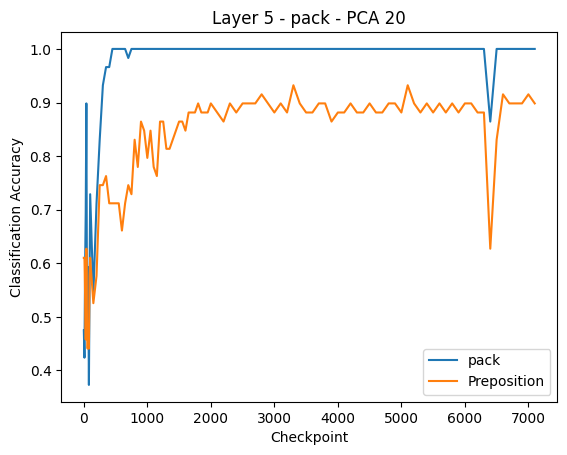

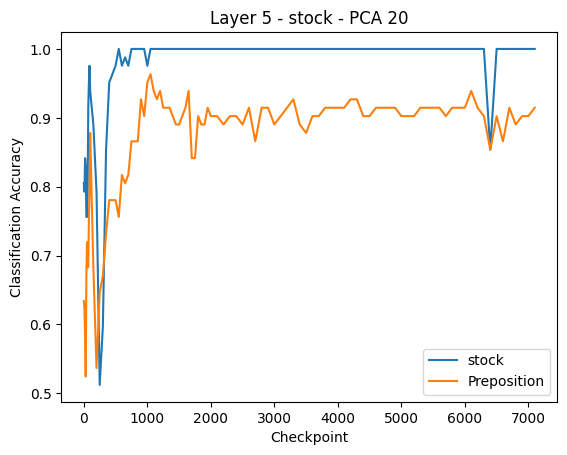

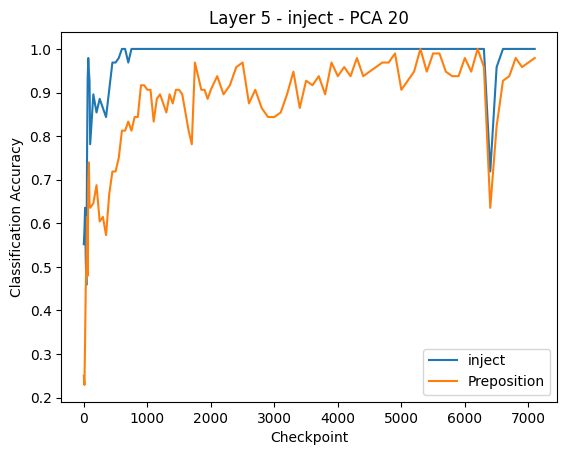

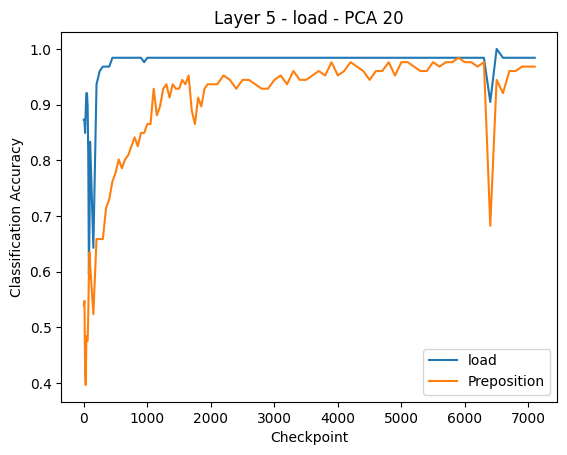

In [15]:
substance_over_20 = [x for x in substance_counts if substance_counts[x] > 10]
pca20_dep = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/lemma/battlestar_small.with.substance.with.adjunct.dependent.tsv"
pca20_target = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/lemma/battlestar_small.with.substance.with.adjunct.target.tsv"

# plot all of these onto a single plot with subplots

print("Substance with")
for lemma in substance_over_20:
    plot_specific_lemma_curves(pca20_dep, pca20_target, 5, lemma, pca=20, x_max=100, normalize=False)

Counter({'load': 126, 'inject': 96, 'stock': 82, 'pack': 59, 'spray': 46, 'plant': 38, 'shower': 37, 'stuff': 30, 'hang': 20, 'stack': 17, 'smear': 16, 'wrap': 14, 'plaster': 13, 'rub': 13, 'seed': 12, 'crowd': 12, 'sprinkle': 12, 'jam': 11, 'scatter': 11, 'drape': 6, 'pump': 6, 'splash': 5, 'heap': 5, 'cram': 5, 'dust': 5, 'squirt': 4, 'sow': 3, 'strew': 2, 'spatter': 2, 'slather': 1, 'smudge': 1, 'sew': 1, 'string': 1, 'daub': 1})
PearsonRResult(statistic=0.6302115216843955, pvalue=0.1292408066078466)


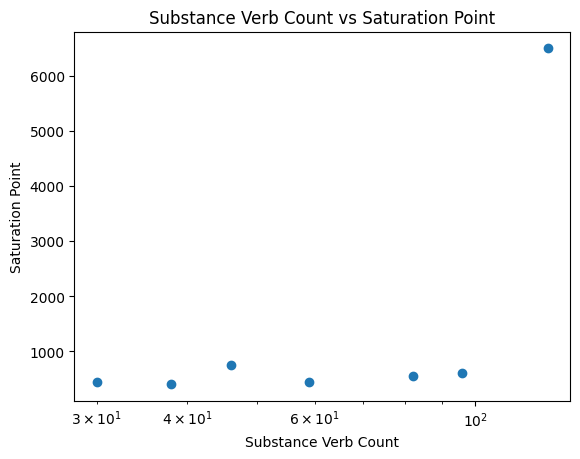

In [65]:
substance_saturation_points = {}

for lemma in substance_over_20:
    saturation_point = get_checkpoint_1_0(pca20_dep, 5, lemma)
    substance_saturation_points[lemma] = saturation_point


all_substance_path=substance_json_path
all_substance = json.load(open(all_substance_path, "r"))

all_substance_counts = Counter([x["dependent_lemma"] for x in all_substance])

print(all_substance_counts)

# plot a correlation between the ditrans counts and ditrans saturation points

x = []
y = []

for lemma in substance_saturation_points:
    if lemma in all_substance_counts and substance_saturation_points[lemma] != None:
        x.append(all_substance_counts[lemma])
        y.append(substance_saturation_points[lemma])

log_freq = [math.log(x) for x in x]
print(pearsonr(log_freq, y))

plt.scatter(x, y)
plt.xlabel("Substance Verb Count")
plt.xscale("log")
plt.ylabel("Saturation Point")
plt.title("Substance Verb Count vs Saturation Point")
plt.show()
